<center><h1>DSCI 552 - HW1</h1></center>

Name: Sanchit Bagai

USC ID: 1033382623

### (a) Download Data

Package imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    f1_score
)

Get the Vertebral Column Data Set

In [2]:
df = pd.read_csv("data/column_2C.dat", sep = r"\s+", header = None)

feature_names = [
    "pelvic_incidence",
    "pelvic_tilt",
    "lumbar_lordosis_angle",
    "sacral_slope",
    "pelvic_radius",
    "degree_spondylolisthesis"
]

df.columns = feature_names + ["class"]
df = df[df["class"].isin(["NO", "AB"])].copy()
df["class"] = df["class"].map({"NO": 0, "AB": 1})

print(df.head())
print(df["class"].value_counts())

X = df[feature_names].values
y = df["class"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

   pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
0             63.03        22.55                  39.61         40.48   
1             39.06        10.06                  25.02         29.00   
2             68.83        22.22                  50.09         46.61   
3             69.30        24.65                  44.31         44.64   
4             49.71         9.65                  28.32         40.06   

   pelvic_radius  degree_spondylolisthesis  class  
0          98.67                     -0.25      1  
1         114.41                      4.56      1  
2         105.99                     -3.53      1  
3         101.87                     11.21      1  
4         108.17                      7.92      1  
class
1    210
0    100
Name: count, dtype: int64
X shape: (310, 6)
y shape: (310,)


### (b) Pre-Processing and Exploratory Data Analysis

#### i. Scatterplots

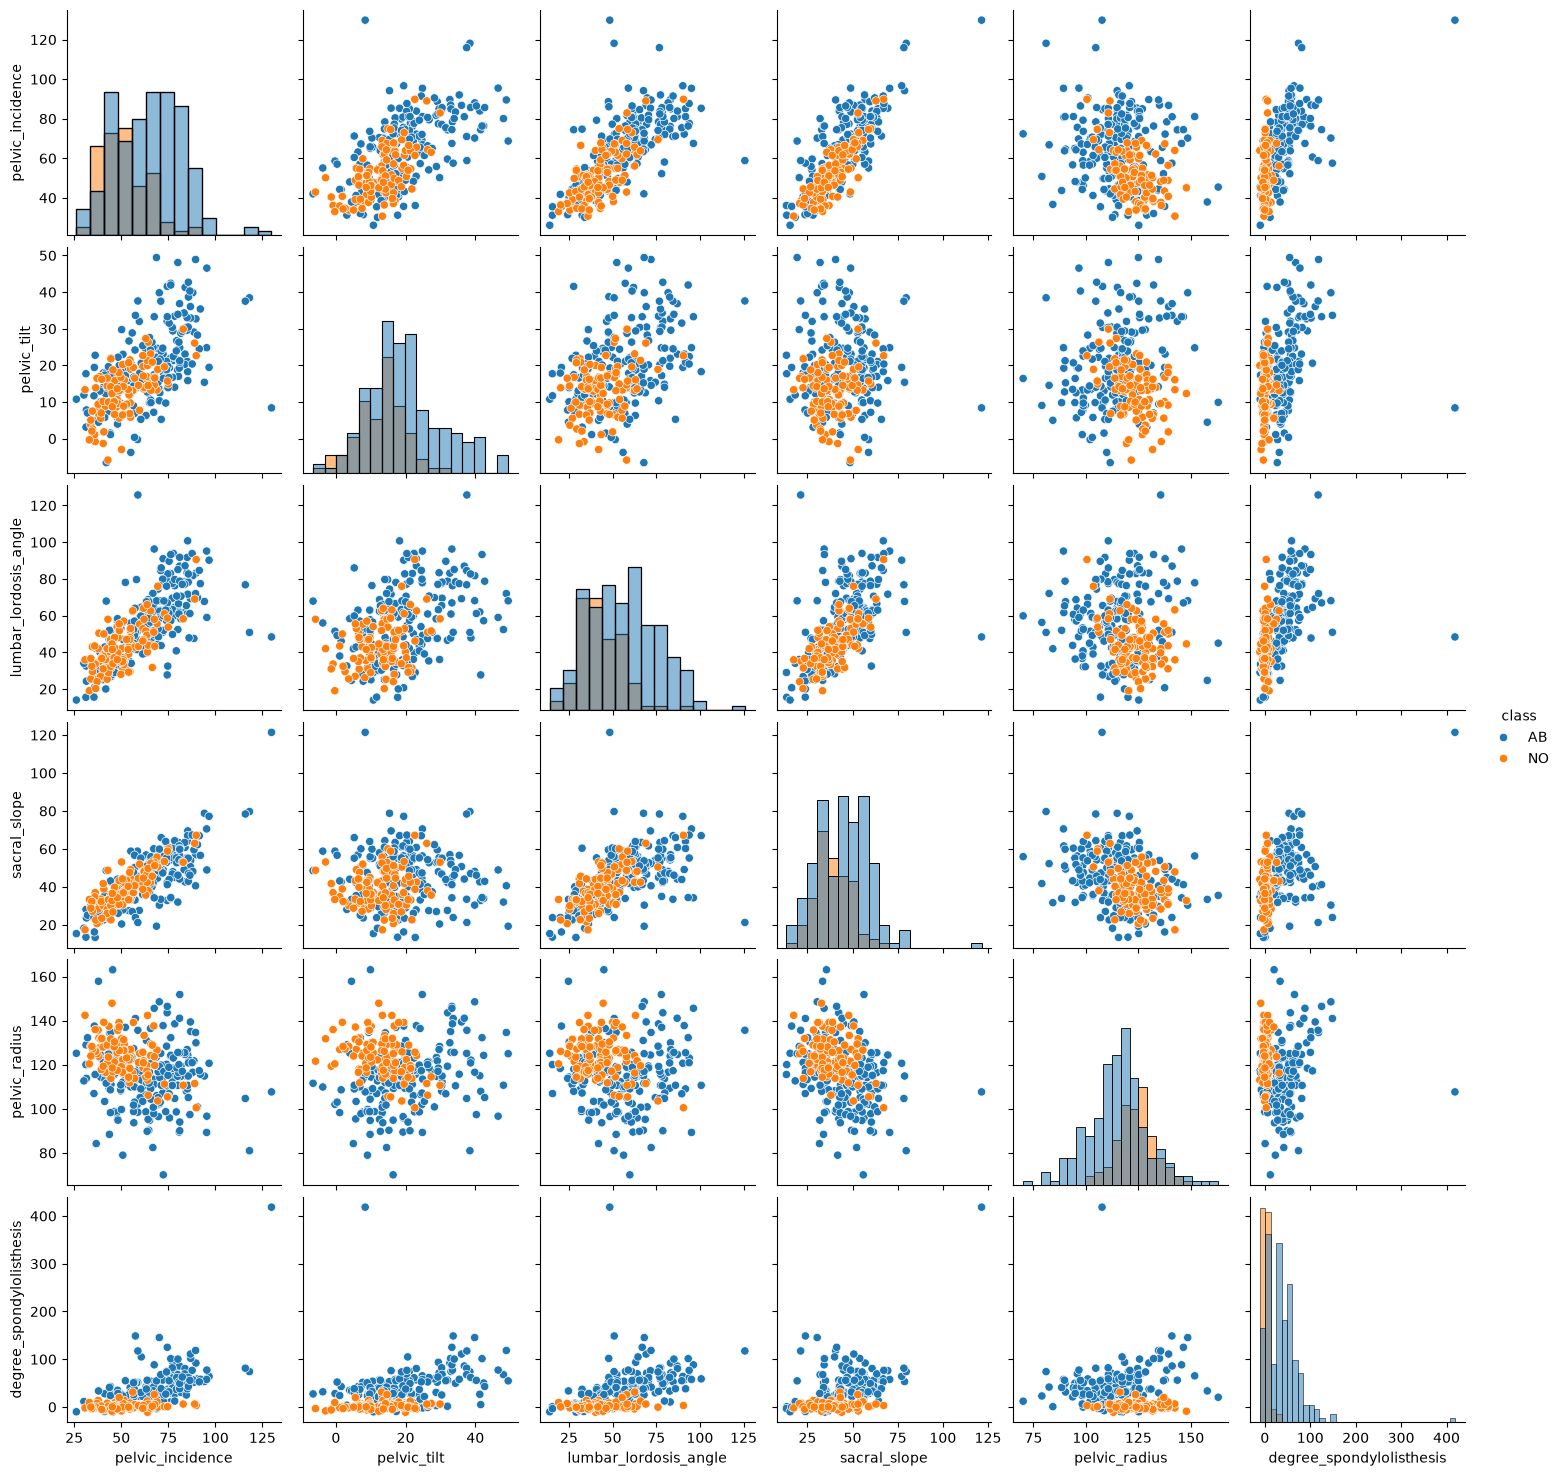

In [3]:
plot_df = df.copy()
plot_df["class"] = plot_df["class"].map({0: "NO", 1: "AB"})

sns.pairplot(
    plot_df,
    vars=feature_names,
    hue="class",
    diag_kind="hist"
)

plt.show()

#### ii. Boxplots

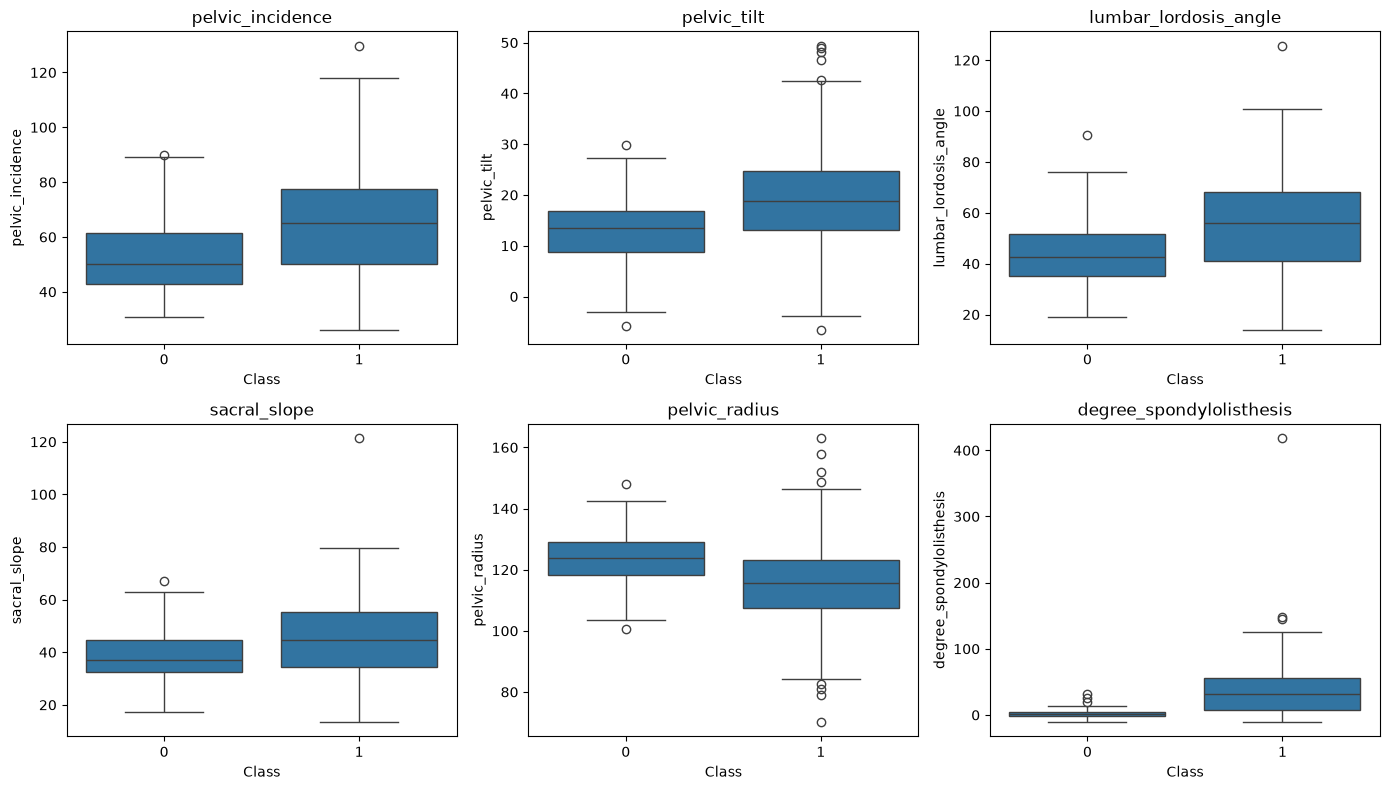

In [4]:
plt.figure(figsize=(14, 8))

for i, feature in enumerate(feature_names, 1):
    plt.subplot(2, 3, i)

    sns.boxplot(
        data=df,
        x="class",
        y=feature
    )

    plt.title(feature)
    plt.xlabel("Class")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

#### iii. Split Data Set

In [5]:
class_0 = df[df["class"] == 0]
class_1 = df[df["class"] == 1]

train_0 = class_0.iloc[:70]
train_1 = class_1.iloc[:140]

train_df = pd.concat([train_0, train_1])

test_0 = class_0.iloc[70:]
test_1 = class_1.iloc[140:]

test_df = pd.concat([test_0, test_1])

X_train = train_df[feature_names].values
y_train = train_df["class"].values

X_test = test_df[feature_names].values
y_test = test_df["class"].values

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class counts:")
print(pd.Series(y_train).value_counts())

print("\nTest class counts:")
print(pd.Series(y_test).value_counts())

Training set: (210, 6)
Test set: (100, 6)

Training class counts:
1    140
0     70
Name: count, dtype: int64

Test class counts:
1    70
0    30
Name: count, dtype: int64


### (c) Classification

#### i. Euclidean Metric

In [6]:
knn = KNeighborsClassifier(
    n_neighbors=1,
    metric="minkowski",
    p=2
)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test error:", 1 - accuracy_score(y_test, y_pred))

Test accuracy: 0.87
Test error: 0.13


#### ii. Test Data

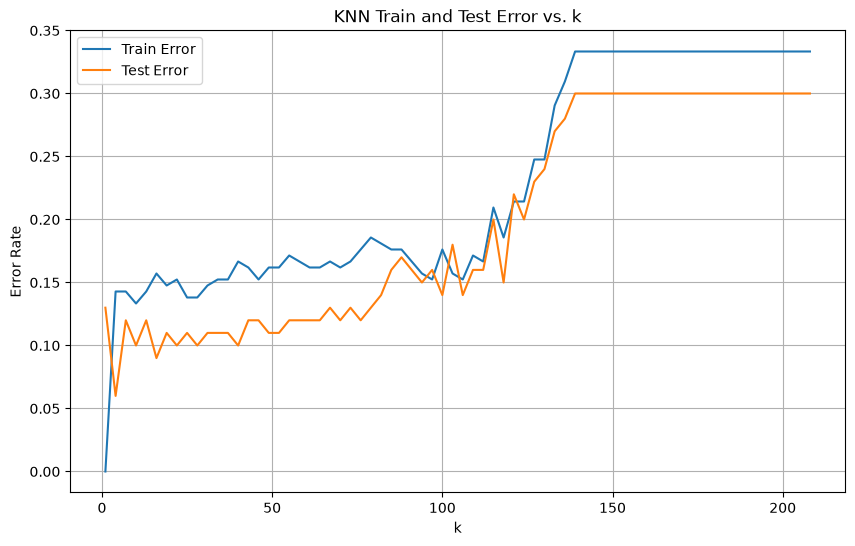

Best k: 4
Best test error: 0.06000000000000005
Training error at best k: 0.1428571428571429
Best k: 4

Confusion Matrix:
[[25  5]
 [ 1 69]]

True Positive Rate: 0.9857142857142858
True Negative Rate: 0.8333333333333334
Precision: 0.9324324324324325
F1-score: 0.9583333333333334


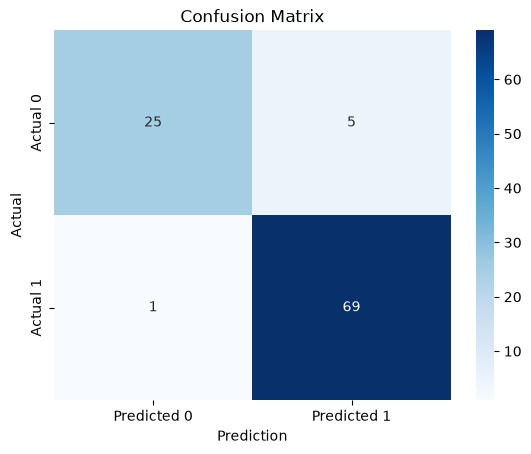

In [7]:
k_values = list(range(208, 0, -3))

train_errors = []
test_errors = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="minkowski",
        p=2
    )

    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    train_errors.append(1 - accuracy_score(y_train, train_pred))
    test_errors.append(1 - accuracy_score(y_test, test_pred))

plt.figure(figsize=(10, 6))

plt.plot(k_values, train_errors, label="Train Error")
plt.plot(k_values, test_errors, label="Test Error")

plt.xlabel("k")
plt.ylabel("Error Rate")
plt.title("KNN Train and Test Error vs. k")
plt.legend()
plt.grid(True)

plt.show()

best_idx = np.argmin(test_errors)

best_k = list(k_values)[best_idx]
best_test_error = test_errors[best_idx]
best_train_error = train_errors[best_idx]

print("Best k:", best_k)
print("Best test error:", best_test_error)
print("Training error at best k:", best_train_error)

knn_best = KNeighborsClassifier(
    n_neighbors=best_k,
    metric="minkowski",
    p=2
)

knn_best.fit(X_train, y_train)

y_pred_best = knn_best.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

tn, fp, fn, tp = cm.ravel()

tpr = tp / (tp + fn)
tnr = tn / (tn + fp)
precision = tp / (tp + fp)
f1 = f1_score(y_test, y_pred_best)

print("Best k:", best_k)

print("\nConfusion Matrix:")
print(cm)

print("\nTrue Positive Rate:", tpr)
print("True Negative Rate:", tnr)
print("Precision:", precision)
print("F1-score:", f1)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### iii. Learning Curve

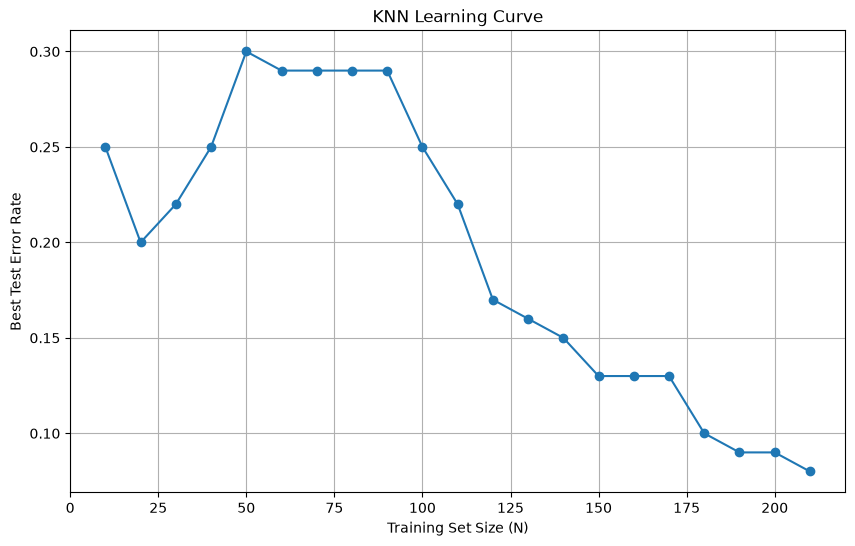

      N  Best k  Best Test Error
0    10       1             0.25
1    20       6             0.20
2    30       1             0.22
3    40      11             0.25
4    50      26             0.30
5    60      21             0.29
6    70      26             0.29
7    80      31             0.29
8    90      41             0.29
9   100       6             0.25
10  110       6             0.22
11  120      16             0.17
12  130      16             0.16
13  140      16             0.15
14  150      16             0.13
15  160       6             0.13
16  170       6             0.13
17  180       6             0.10
18  190       6             0.09
19  200       6             0.09
20  210       6             0.08


In [8]:
N_values = range(10, 211, 10)

learning_curve_errors = []
learning_curve_best_k = []

for N in N_values:

    n_class0 = N // 3
    n_class1 = N - n_class0

    subset_0 = train_0.iloc[:n_class0]
    subset_1 = train_1.iloc[:n_class1]

    subset_train = pd.concat([subset_0, subset_1])

    X_subset = subset_train[feature_names].values
    y_subset = subset_train["class"].values

    k_values_subset = list(range(1, N, 5))

    best_error = np.inf
    best_k_subset = None

    for k in k_values_subset:

        if k > len(X_subset):
            continue

        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric="minkowski",
            p=2
        )

        knn.fit(X_subset, y_subset)

        test_pred = knn.predict(X_test)

        error = 1 - accuracy_score(y_test, test_pred)

        if error < best_error:
            best_error = error
            best_k_subset = k

    learning_curve_errors.append(best_error)
    learning_curve_best_k.append(best_k_subset)
plt.figure(figsize=(10, 6))

plt.plot(
    N_values,
    learning_curve_errors,
    marker="o"
)

plt.xlabel("Training Set Size (N)")
plt.ylabel("Best Test Error Rate")
plt.title("KNN Learning Curve")
plt.grid(True)

plt.show()

learning_curve_results = pd.DataFrame({
    "N": N_values,
    "Best k": learning_curve_best_k,
    "Best Test Error": learning_curve_errors
})

print(learning_curve_results)

### (d) Other Metrics

#### i. Minkowski Distance.

##### A. Manhattan Distance with p = 1.

In [9]:
k_values_d = list(range(1, 197, 5))

manhattan_errors = []

for k in k_values_d:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="minkowski",
        p=1
    )

    knn.fit(X_train, y_train)

    test_pred = knn.predict(X_test)

    error = 1 - accuracy_score(y_test, test_pred)

    manhattan_errors.append(error)

best_idx = np.argmin(manhattan_errors)

best_k_manhattan = k_values_d[best_idx]
best_error_manhattan = manhattan_errors[best_idx]

print("Best k (Manhattan):", best_k_manhattan)
print("Best test error (Manhattan):", best_error_manhattan)

Best k (Manhattan): 6
Best test error (Manhattan): 0.10999999999999999


##### B. With log10(p) in {0.1, 0.2, 0.3, ... ,1}.

In [10]:
log10_p_values = np.arange(0.1, 1.01, 0.1)

p_values = 10 ** log10_p_values

minkowski_results = []

for p in p_values:

    knn = KNeighborsClassifier(
        n_neighbors=best_k_manhattan,
        metric="minkowski",
        p=p
    )

    knn.fit(X_train, y_train)

    test_pred = knn.predict(X_test)

    error = 1 - accuracy_score(y_test, test_pred)

    minkowski_results.append(error)
minkowski_df = pd.DataFrame({
    "log10(p)": log10_p_values,
    "p": p_values,
    "Test Error": minkowski_results
})

print(minkowski_df)

best_p_idx = np.argmin(minkowski_results)

best_log10_p = log10_p_values[best_p_idx]
best_p = p_values[best_p_idx]
best_p_error = minkowski_results[best_p_idx]

print("Best log10(p):", best_log10_p)
print("Best p:", best_p)
print("Test error:", best_p_error)

   log10(p)          p  Test Error
0       0.1   1.258925        0.09
1       0.2   1.584893        0.09
2       0.3   1.995262        0.08
3       0.4   2.511886        0.08
4       0.5   3.162278        0.08
5       0.6   3.981072        0.06
6       0.7   5.011872        0.07
7       0.8   6.309573        0.08
8       0.9   7.943282        0.09
9       1.0  10.000000        0.09
Best log10(p): 0.6
Best p: 3.9810717055349722
Test error: 0.06000000000000005


##### C. Chebyshev Distance With p -> infinity.

In [11]:
chebyshev_errors = []

for k in k_values_d:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="chebyshev"
    )

    knn.fit(X_train, y_train)

    test_pred = knn.predict(X_test)

    error = 1 - accuracy_score(y_test, test_pred)

    chebyshev_errors.append(error)

best_idx = np.argmin(chebyshev_errors)

best_k_chebyshev = k_values_d[best_idx]
best_error_chebyshev = chebyshev_errors[best_idx]

print("Best k (Chebyshev):", best_k_chebyshev)
print("Best test error (Chebyshev):", best_error_chebyshev)

Best k (Chebyshev): 16
Best test error (Chebyshev): 0.07999999999999996


#### ii. Mahalanobis Distance.

In [12]:
cov_matrix = np.cov(X_train, rowvar=False)

# Pseudoinverse is safer than a direct inverse
VI = np.linalg.pinv(cov_matrix)

mahalanobis_errors = []

for k in k_values_d:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="mahalanobis",
        metric_params={"VI": VI}
    )

    knn.fit(X_train, y_train)

    test_pred = knn.predict(X_test)

    error = 1 - accuracy_score(y_test, test_pred)

    mahalanobis_errors.append(error)

best_idx = np.argmin(mahalanobis_errors)

best_k_mahalanobis = k_values_d[best_idx]
best_error_mahalanobis = mahalanobis_errors[best_idx]

print("Best k (Mahalanobis):", best_k_mahalanobis)
print("Best test error (Mahalanobis):", best_error_mahalanobis)

Best k (Mahalanobis): 1
Best test error (Mahalanobis): 0.17000000000000004


##### Result Table

In [13]:
distance_results = pd.DataFrame({
    "Distance": [
        "Manhattan",
        "Minkowski (best p)",
        "Chebyshev",
        "Mahalanobis"
    ],
    "Best k": [
        best_k_manhattan,
        best_k_manhattan,
        best_k_chebyshev,
        best_k_mahalanobis
    ],
    "Test Error": [
        best_error_manhattan,
        best_p_error,
        best_error_chebyshev,
        best_error_mahalanobis
    ]
})

print(distance_results)

             Distance  Best k  Test Error
0           Manhattan       6        0.11
1  Minkowski (best p)       6        0.06
2           Chebyshev      16        0.08
3         Mahalanobis       1        0.17


### (e) Weighted Decision

In [14]:
weighted_euclidean_errors = []

for k in k_values_d:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="minkowski",
        p=2,
        weights="distance"
    )

    knn.fit(X_train, y_train)

    test_pred = knn.predict(X_test)

    error = 1 - accuracy_score(y_test, test_pred)

    weighted_euclidean_errors.append(error)

best_idx = np.argmin(weighted_euclidean_errors)

best_k_weighted_euclidean = k_values_d[best_idx]
best_error_weighted_euclidean = weighted_euclidean_errors[best_idx]

print("Best k:", best_k_weighted_euclidean)
print("Best test error:", best_error_weighted_euclidean)

weighted_manhattan_errors = []

for k in k_values_d:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="minkowski",
        p=1,
        weights="distance"
    )

    knn.fit(X_train, y_train)

    test_pred = knn.predict(X_test)

    error = 1 - accuracy_score(y_test, test_pred)

    weighted_manhattan_errors.append(error)

best_idx = np.argmin(weighted_manhattan_errors)

best_k_weighted_manhattan = k_values_d[best_idx]
best_error_weighted_manhattan = weighted_manhattan_errors[best_idx]

print("Best k:", best_k_weighted_manhattan)
print("Best test error:", best_error_weighted_manhattan)

weighted_chebyshev_errors = []

for k in k_values_d:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="chebyshev",
        weights="distance"
    )

    knn.fit(X_train, y_train)

    test_pred = knn.predict(X_test)

    error = 1 - accuracy_score(y_test, test_pred)

    weighted_chebyshev_errors.append(error)

best_idx = np.argmin(weighted_chebyshev_errors)

best_k_weighted_chebyshev = k_values_d[best_idx]
best_error_weighted_chebyshev = weighted_chebyshev_errors[best_idx]

print("Best k:", best_k_weighted_chebyshev)
print("Best test error:", best_error_weighted_chebyshev)

weighted_results = pd.DataFrame({
    "Distance": [
        "Weighted Euclidean",
        "Weighted Manhattan",
        "Weighted Chebyshev"
    ],
    "Best k": [
        best_k_weighted_euclidean,
        best_k_weighted_manhattan,
        best_k_weighted_chebyshev
    ],
    "Best Test Error": [
        best_error_weighted_euclidean,
        best_error_weighted_manhattan,
        best_error_weighted_chebyshev
    ]
})

print(weighted_results)

Best k: 6
Best test error: 0.09999999999999998
Best k: 26
Best test error: 0.09999999999999998
Best k: 16
Best test error: 0.10999999999999999
             Distance  Best k  Best Test Error
0  Weighted Euclidean       6             0.10
1  Weighted Manhattan      26             0.10
2  Weighted Chebyshev      16             0.11


### (f) Training Error Rate

In [15]:
lowest_training_error = min(train_errors)
k_lowest_training_error = list(k_values)[np.argmin(train_errors)]

print("Lowest training error:", lowest_training_error)
print("k:", k_lowest_training_error)

Lowest training error: 0.0
k: 1


Same excluding $k=1$ because it gives zero training error by using each training point itself as its nearest neighbor.

In [16]:
k_values_without_1 = [k for k in k_values if k != 1]
train_errors_without_1 = [error for k, error in zip(k_values, train_errors) if k != 1]

lowest_training_error = min(train_errors_without_1)
k_lowest_training_error = k_values_without_1[np.argmin(train_errors_without_1)]

print("Lowest training error (excluding k=1):", lowest_training_error)
print("k:", k_lowest_training_error)

Lowest training error (excluding k=1): 0.1333333333333333
k: 10


### AI Use log:

**Prompt:**

I’ve attached my assignment PDF. Can you walk me through how to approach parts (c) through (f) without solving them? Explain the steps I should take for the KNN classification, selecting $k$, learning curve, alternative distance metrics, weighted voting, and training error. Include relevant Python/scikit-learn functions and suggested variable names so I can implement and test the solution myself.

(Uploaded hw1.pdf for context)

**Response:**

## (c) Classification Using K-Nearest Neighbors

### (i) Euclidean Metric

`KNeighborsClassifier` is used to perform K-nearest neighbors classification. Setting `metric="minkowski"` with `p=2` specifies Euclidean distance. The classifier is fitted using `X_train` and `y_train`, and predictions for the test set are stored in `y_pred`.

Test error is calculated as:

$$
\text{Test Error} = 1-\text{Accuracy}
$$

### (ii) Train and Test Error

`k_values` defines the neighborhood sizes evaluated by the classifier. For each value of $k$, predictions are generated for both the training and test sets.

`train_errors` stores the training error rate for each $k$, while `test_errors` stores the corresponding test error rate. These values are plotted against `k_values` to examine the effect of neighborhood size on classification performance.

#### Optimal $k$

`best_idx` gives the index of the minimum value in `test_errors`. The corresponding neighborhood size is stored in `best_k`.

- `best_k`: value of $k$ with minimum test error
- `best_test_error`: minimum test error
- `best_train_error`: training error corresponding to `best_k`

#### Classification Metrics

`knn_best` represents the Euclidean KNN classifier using `best_k`. Predictions on `X_test` are stored in `y_pred_best`.

The confusion matrix `cm` is decomposed into:

- `tn`: true negatives
- `fp`: false positives
- `fn`: false negatives
- `tp`: true positives

The following performance measures are then calculated:

$$
TPR=\frac{TP}{TP+FN}
$$

$$
TNR=\frac{TN}{TN+FP}
$$

$$
Precision=\frac{TP}{TP+FP}
$$

`f1` stores the F1-score calculated from the test predictions.

### (iii) Learning Curve

`N_values` defines the training-set sizes used to construct the learning curve. For each `N`:

- `n_class0` specifies the number of Class 0 observations.
- `n_class1` specifies the number of Class 1 observations.
- `subset_train` contains the selected observations.
- `X_subset` and `y_subset` contain the corresponding features and labels.

`k_values_subset` defines the candidate neighborhood sizes for each value of `N`. `best_k_subset` stores the value of $k$ producing the smallest test error for the current training-set size, and `best_error` stores that error.

`learning_curve_best_k` and `learning_curve_errors` collect these values across all training-set sizes. `learning_curve_results` summarizes the resulting learning curve.

---

## (d) Alternative Distance Metrics

### (i)(A) Manhattan Distance

Manhattan distance is represented as Minkowski distance with `p=1`.

`manhattan_errors` contains the test error obtained for each value in `k_values_d`. `best_k_manhattan` identifies the neighborhood size with minimum test error, and `best_error_manhattan` stores the corresponding error.

### (i)(B) Minkowski Distance

`log10_p_values` defines the values of $\log_{10}(p)$ being evaluated. `p_values` contains their corresponding Minkowski parameters:

$$
p=10^{\log_{10}(p)}
$$

`best_k_manhattan` is held constant while each value of `p_values` is evaluated.

- `minkowski_results`: test errors for the candidate values of $p$
- `best_log10_p`: value of $\log_{10}(p)$ producing minimum test error
- `best_p`: corresponding value of $p$
- `best_p_error`: minimum test error

### (i)(C) Chebyshev Distance

Chebyshev distance is specified using `metric="chebyshev"` and corresponds to the limiting case of Minkowski distance as $p\rightarrow\infty$.

`chebyshev_errors` contains the test errors for the values in `k_values_d`. `best_k_chebyshev` and `best_error_chebyshev` contain the neighborhood size and test error of the best-performing classifier.

### (ii) Mahalanobis Distance

`cov_matrix` contains the covariance matrix calculated from `X_train`. `VI` contains its pseudoinverse and is supplied to the Mahalanobis distance calculation through `metric_params`.

- `mahalanobis_errors`: test errors for each candidate $k$
- `best_k_mahalanobis`: $k$ producing minimum test error
- `best_error_mahalanobis`: corresponding minimum test error

### Distance Metric Results

`distance_results` summarizes the optimal neighborhood size and test error obtained using Manhattan, Minkowski, Chebyshev, and Mahalanobis distances.

---

## (e) Weighted Decision

Distance-weighted KNN uses `weights="distance"` so that the contribution of a neighbor to the classification decision is inversely related to its distance from the query observation.

### Euclidean

`weighted_euclidean_errors` contains the test errors obtained using Euclidean distance (`p=2`).

- `best_k_weighted_euclidean`: optimal neighborhood size
- `best_error_weighted_euclidean`: corresponding test error

### Manhattan

`weighted_manhattan_errors` contains the test errors obtained using Manhattan distance (`p=1`).

- `best_k_weighted_manhattan`: optimal neighborhood size
- `best_error_weighted_manhattan`: corresponding test error

### Chebyshev

`weighted_chebyshev_errors` contains the test errors obtained using Chebyshev distance.

- `best_k_weighted_chebyshev`: optimal neighborhood size
- `best_error_weighted_chebyshev`: corresponding test error

### Weighted KNN Results

`weighted_results` summarizes the optimal $k$ and minimum test error for each weighted distance metric.

---

## (f) Training Error Rate

`train_errors` contains the training errors obtained during the Euclidean KNN evaluation.

- `lowest_training_error`: minimum training error
- `k_lowest_training_error`: value of $k$ at which the minimum training error occurs

At $k=1$, each training observation is its own nearest neighbor, resulting in a training error of zero.

### References:
- scikit documentation: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html